In [ ]:
import os
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import sys

import glob
import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys# less gpu heavy loss, SAM doesnt look good 
import glob

from torch.utils.data import Dataset
from typing import Optional, Callable, List, Dict, Tuple, Any
from tqdm import tqdm
import json
import wandb
from torchvision.utils import make_grid

from torchmetrics.image import StructuralSimilarityIndexMeasure
from metrics.sam import SAMScore

torch.cuda.empty_cache()

In [2]:
! export CODE_PATH="/media/ana-caznok/SSD-08/recon-segment"
! export DATA_PATH="/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2"

In [ ]:
# Set visible CUDA devices
#os.environ["CUDA_VISIBLE_DEVICES"] = config["gpus"]
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/transforms")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/configs")
sys.path.append("/media/ana-caznok/SSD-08/recon-segment/plots")

In [4]:
from fixed_dataset import FixedDataset
from seg_recon_vit3d import SegRecon_ViT_3D
from transforms.factory import transform_factory
from utils.read_yaml import read_yaml
from utils.model_select import model_select
from loss import loss_select

/home/ana-caznok/software/src/miniforge3/envs/agrvai/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
config_path = "/media/ana-caznok/SSD-08/recon-segment/configs/"
config_name = 'test.yaml'
config_file = config_name

In [6]:
config = read_yaml(config_path + config_name)

In [7]:
# --------------------- CONFIG ---------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = "/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2"
PREPROCESSING = config['preprocessing']  # or None or "downsampled"
BATCH_SIZE = 1#config['train']['batch_size']
NUM_EPOCHS = 2#config['train']['epochs']
LEARNING_RATE = config['train']['lr']
SAVE_PATH = config['fixed_checkpoint_name']
TRANSFORM = 'downs4_fft_double_normal_minmax_cube_gpu_shift' #config['train']['transform_index']
MODEL_NAME = config['model']

In [8]:
print(transform_factory(TRANSFORM))


0: Downsample by a factor of 4
1: RGB2Pseudo_Hyp with: /media/ana-caznok/SSD-08/recon-segment/ and camera norm
2: FourierSpectralTransform(norm=minmax,double RealImag=True ,transform cube=True, device=cpu, shift=True,stack_type=alternate, invert=False )


## ------------------ DATASET + LOADER ------------------

In [9]:
# ------------------ DATASET + LOADER ------------------
train_dataset = FixedDataset(
    mode="train",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),  # You can define transforms here
    preprocessing=PREPROCESSING
)

val_dataset = FixedDataset(
    mode="val",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),
    preprocessing=PREPROCESSING
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Loading from hdf files
Number of face masks 234. 

Checking face mask integrity...: 234it [00:00, 1220730.27it/s]


initialized 234 images train DatasetRaw with preprocessing: h5py in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2 with transform 
0: Downsample by a factor of 4
1: RGB2Pseudo_Hyp with: /media/ana-caznok/SSD-08/recon-segment/ and camera norm
2: FourierSpectralTransform(norm=minmax,double RealImag=True ,transform cube=True, device=cpu, shift=True,stack_type=alternate, invert=False ). Fold: None
Loading from hdf files
Number of face masks 30. 

Checking face mask integrity...: 30it [00:00, 577197.80it/s]

initialized 30 images val DatasetRaw with preprocessing: h5py in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2 with transform 
0: Downsample by a factor of 4
1: RGB2Pseudo_Hyp with: /media/ana-caznok/SSD-08/recon-segment/ and camera norm
2: FourierSpectralTransform(norm=minmax,double RealImag=True ,transform cube=True, device=cpu, shift=True,stack_type=alternate, invert=False ). Fold: None


## ------------------ TESTING TRANSFORM ------------------

torch.Size([62, 256, 256])
torch.Size([122, 256, 256])


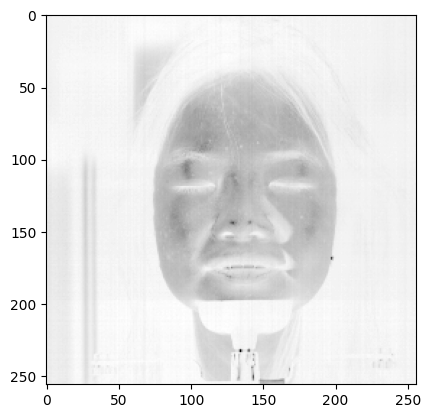

In [10]:
# ------------------ TESTING TRANSFORM ------------------
x, y, m = train_dataset[45]
print(x.shape)
print(y.shape)
x = x.cpu().numpy()
plt.imshow(x[21],cmap='gray')
plt.show()

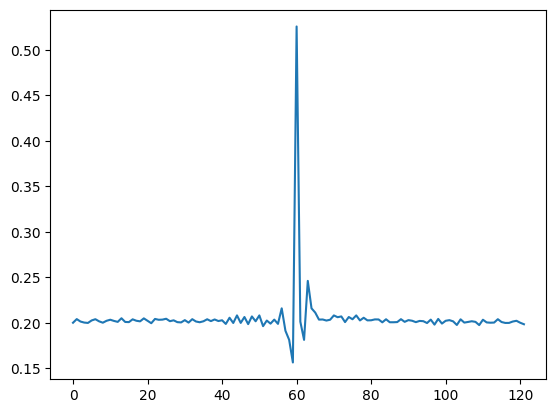

In [11]:
plt.plot(y[:,145,145])
plt.show()

## -------------- TESTING INVERSE TRANSFORM ----------------- 

In [ ]:
#-------------- TESTING INVERSE TRANSFORM ----------------- 

In [20]:
original_dataset = FixedDataset(
    mode="train",
    base_path=BASE_PATH,
    transform=transform_factory('downsample_4'),  # You can define transforms here
    preprocessing=PREPROCESSING
)
x_oritinal, y_original, m_original = original_dataset[45]
y_original = y_original.cpu().numpy()
print(x_oritinal.shape)
print(y_original.shape)

Loading from hdf files
Number of face masks 234. 

Checking face mask integrity...: 234it [00:00, 1266409.21it/s]

initialized 234 images train DatasetRaw with preprocessing: h5py in /media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2 with transform Downsample by a factor of 4. Fold: None
torch.Size([4, 256, 256])
(61, 256, 256)


In [13]:
from ifft_transform import InverseFourierSpectralTransform
inverse_transform = InverseFourierSpectralTransform(
                        norm = 'minmax',
                        channel_first = True, 
                        device = 'cpu', 
                        shift = False, 
                        stack_type = 'alternate')
inverse_transform_shift = InverseFourierSpectralTransform(
                        norm = 'minmax',
                        channel_first = True, 
                        device = 'cpu', 
                        shift = True, 
                        stack_type = 'alternate')

In [14]:
y.shape

torch.Size([122, 256, 256])

In [16]:
y_ifft  = inverse_transform(y,m).cpu().numpy()
y_ifft_shift = inverse_transform_shift(y,m).cpu().numpy()

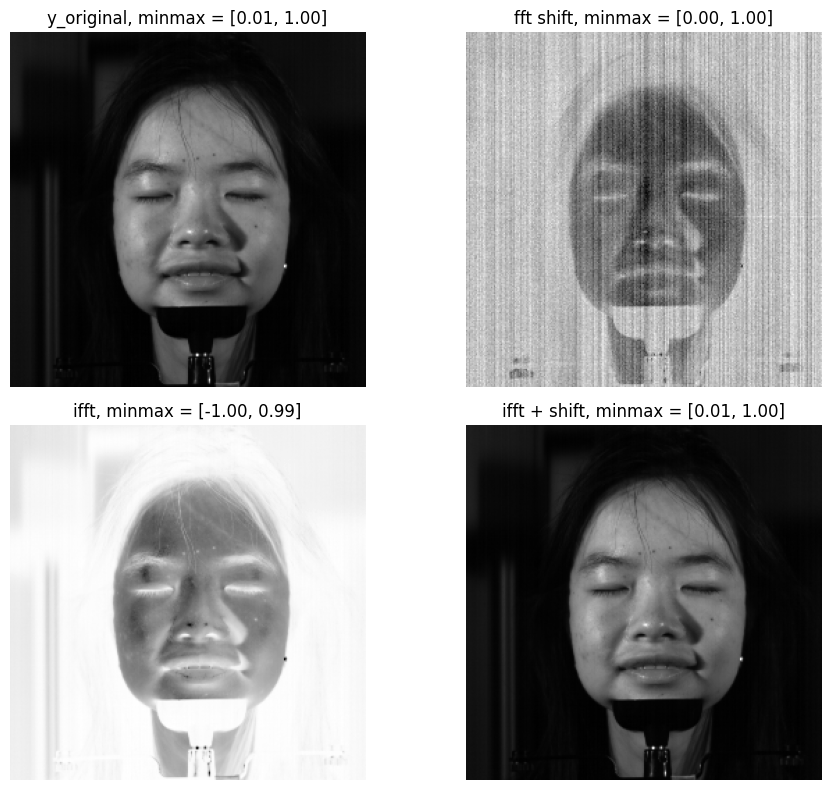

In [21]:
import matplotlib.pyplot as plt

# Create a 2x2 grid of subplots with specified figure size
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot y_original[21, :, :] with grayscale colormap
axes[0, 0].imshow(y_original[21,:,:], cmap='gray')
imin, imax = y_original.min(), y_original.max()
axes[0, 0].set_title(f"y_original, minmax = [{imin:.2f}, {imax:.2f}]")
axes[0, 0].axis('off')  # Remove axis ticks

# Plot y[21, :, :]
axes[0, 1].imshow(y[21, :, :], cmap='gray')
imin, imax = y.min(), y.max()
axes[0, 1].set_title(f"fft shift, minmax = [{imin:.2f}, {imax:.2f}]")
axes[0, 1].axis('off')

# Plot y_transformed[21, :, :]
axes[1, 0].imshow(y_ifft[21, :, :], cmap='gray')
imin, imax = y_ifft.min(), y_ifft.max()
axes[1, 0].set_title(f"ifft, minmax = [{imin:.2f}, {imax:.2f}]")
axes[1, 0].axis('off')

# Plot y_transformed_shift[21, :, :]
axes[1, 1].imshow(y_ifft_shift[21, :, :], cmap='gray')
imin, imax = y_ifft_shift.min(), y_ifft_shift.max()
axes[1, 1].set_title(f"ifft + shift, minmax = [{imin:.2f}, {imax:.2f}]")
axes[1, 1].axis('off')

# Optimize spacing between plots
plt.tight_layout()

# Display all subplots in one figure
plt.show()


In [25]:
np.arange(0,60, 10)

array([ 0, 10, 20, 30, 40, 50])

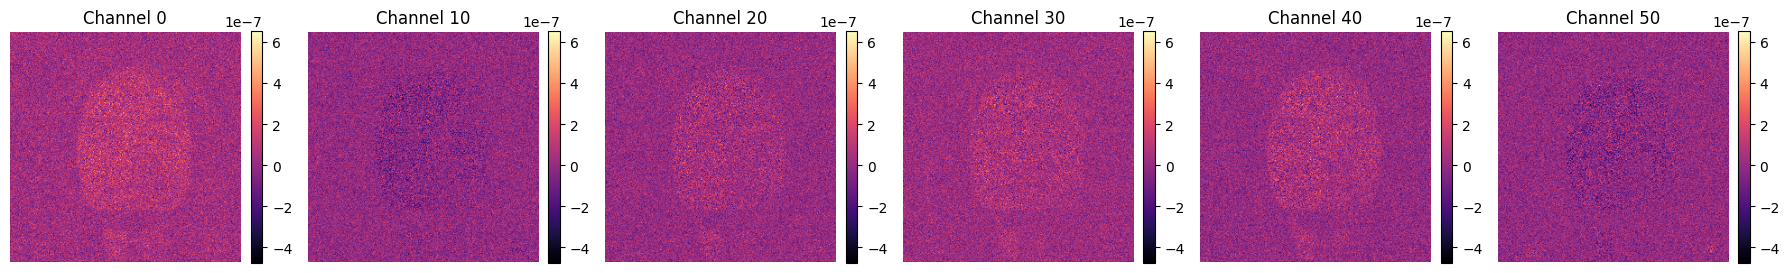

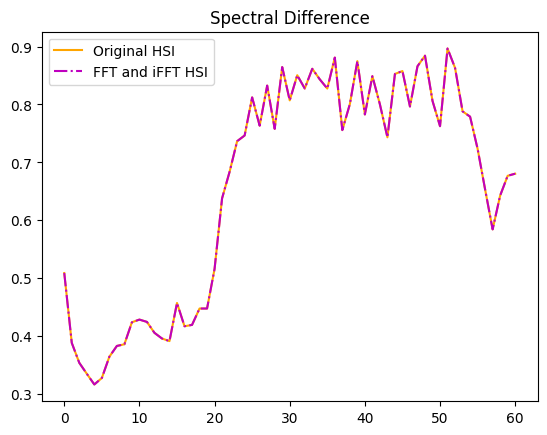

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Assume y_original and y_ifft_shift are NumPy arrays of shape (C, H, W)
# Compute the difference
difference = y_original - y_ifft_shift

# Select the channels to visualize (e.g., every 10th from 0 to 50)
channels = np.arange(0, 60, 10)

# Compute global min and max for consistent color scale across subplots
vmin = np.min(difference[channels])
vmax = np.max(difference[channels])

# Create a subplot with one row and len(channels) columns
n_channels = len(channels)
fig, axes = plt.subplots(1, n_channels, figsize=(3 * n_channels, 3))

# Ensure axes is iterable
if n_channels == 1:
    axes = [axes]

# Plot each channel with the same vmin/vmax scale
for i, ch in enumerate(channels):
    ax = axes[i]
    im = ax.imshow(difference[ch], cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(f'Channel {ch}')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Adjust layout
plt.savefig('/media/ana-caznok/SSD-08/recon-segment/plots/iFFT_difference.png')
plt.tight_layout()
plt.show()

plt.plot(y_original[:,128,128],'orange',label = 'Original HSI')
plt.plot(y_ifft_shift[:,128,128],'-.m', label = 'FFT and iFFT HSI')
plt.legend()
plt.title('Spectral Difference')
plt.savefig('/media/ana-caznok/SSD-08/recon-segment/plots/iFFT_spectral_difference.png')

In [ ]:
#O PROBLEMA EH A NORMALIZACAO DA IMAGEM, se nao fizermos normalizacao, a inversa sai igualzinha a original 
# o unico jeito seria fazer com que a rede ou aprenda entre -inf e + inf 

## ------------------ TESTING MULTIPLE TRANSFORMS ------------------

In [ ]:
# ------------------ TESTING MULTIPLE TRANSFORMS ------------------

BASE_PATH = "/media/ana-caznok/SSD-08/icasp_4090/icasp/data/Link_2"
PREPROCESSING = config['preprocessing']  # or None or "downsampled"
BATCH_SIZE = config['train']['batch_size']
NUM_EPOCHS = config['train']['epochs']
LEARNING_RATE = config['train']['lr']
SAVE_PATH = config['fixed_checkpoint_name']
MODEL_NAME = config['model']

testing_transforms = [
    'downs4_fft_D40_cube_minmax_gpu_shift',                      # D40 reflectance, shifted FFT, minmax
    'downs4_fft_D40_cube_minmax_gpu',                            # D40 reflectance, non-shifted FFT, minmax
    'downs4_fft_normal_cube_minmax_gpu_shift',                  # Normal reflectance, shifted FFT, minmax
    'downs4_fft_normal_cube_minmax_gpu',                        # Normal reflectance, non-shifted FFT, minmax
    'downs4_fft_double_D40_cube_minmax_gpu',                    # D40 reflectance, non-shifted FFT, real+imag
    'downs4_fft_double_D40_cube_gpu_minmax_shift',              # D40 reflectance, shifted FFT, real+imag
    'downs4_fft_double_normal_cube_minmax_gpu',                 # Normal reflectance, non-shifted FFT, real+imag
    'downs4_fft_double_normal_cube_gpu_minmax_shift',           # Normal reflectance, shifted FFT, real+imag
    'downs4_fft_double_normal_cube_gpu_minmax_shift_continuous',# Normal reflectance, shifted FFT, real+imag, continuous stacking
    'downs4_fft_double-softmax_normal_cube_gpu_shift',          # Normal reflectance, shifted FFT, real+imag, softmax normalization
    'downs4_fft_double-none_normal_cube_gpu_shift'    # Normal reflectance, shifted FFT, real+imag, softmax normalization
]
x_transf_dict = {'full_img': {}, 
                 'spectre': {}}
y_transf_dict = {'full_img': {}, 
                 'spectre': {}}

for t in testing_transforms: 
    TRANSFORM = t

    train_dataset = FixedDataset(
    mode="train",
    base_path=BASE_PATH,
    transform=transform_factory(TRANSFORM),  # You can define transforms here
    preprocessing=PREPROCESSING
    )
    
    x, y, m = train_dataset[45]
    x = x.cpu().numpy()
    y = y.cpu().numpy()

    x_transf_dict['full_img'][t] = x
    y_transf_dict['full_img'][t] = y

    x_transf_dict['spectre'][t] = x[:,128,128]
    y_transf_dict['spectre'][t] = y[:,128,128]


    torch.cuda.empty_cache()

In [ ]:

def plot_transform_comparisons(x_transf_dict):
    """
    Plots comparisons of different spectral transforms using the 'spectre' data
    from x_transf_dict based on the new 'testing_transforms' 
    Comparisons include:
    - D40 vs Normal reflectance
    - Shifted vs Non-shifted FFT
    - Real+Imag vs Magnitude
    - Stacking methods (alternate vs continuous)
    - Normalization methods (minmax vs softmax)
    """
    plot_path = '/media/ana-caznok/SSD-08/recon-segment/plots/'
    # Extract the spectral data
    spectre_data = x_transf_dict['spectre']
    
    # Title mapping based on updated keys
    titles = {
        'downs4_fft_D40_cube_minmax_gpu_shift': 'D40, Shifted FFT, Magnitude',
        'downs4_fft_D40_cube_minmax_gpu': 'D40, Non-shifted FFT, Magnitude',
        'downs4_fft_normal_cube_minmax_gpu_shift': 'Normal, Shifted FFT, Magnitude',
        'downs4_fft_normal_cube_minmax_gpu': 'Normal, Non-shifted FFT, Magnitude',
        'downs4_fft_double_D40_cube_minmax_gpu': 'D40, Non-shifted FFT, Real+Imag',
        'downs4_fft_double_D40_cube_gpu_minmax_shift': 'D40, Shifted FFT, Real+Imag',
        'downs4_fft_double_normal_cube_minmax_gpu': 'Normal, Non-shifted FFT, Real+Imag',
        'downs4_fft_double_normal_cube_gpu_minmax_shift': 'Normal, Shifted FFT, Real+Imag',
        'downs4_fft_double_normal_cube_gpu_minmax_shift_continuous': 'Normal, Shifted FFT, Real+Imag, Continuous',
        'downs4_fft_double-softmax_normal_cube_gpu_shift': 'Normal, Shifted FFT, Real+Imag, Softmax',
        'downs4_fft_double-none_normal_cube_gpu_shift': 'Normal, Shifted FFT, Real+Imag, NoNorm',
    }

    # === 1. D40 vs Normal (same FFT and representation) ===
    d40_vs_normal_pairs = [
        ('downs4_fft_D40_cube_minmax_gpu_shift', 'downs4_fft_normal_cube_minmax_gpu_shift'),
        ('downs4_fft_D40_cube_minmax_gpu', 'downs4_fft_normal_cube_minmax_gpu'),
        ('downs4_fft_double_D40_cube_minmax_gpu', 'downs4_fft_double_normal_cube_minmax_gpu'),
        ('downs4_fft_double_D40_cube_gpu_minmax_shift', 'downs4_fft_double_normal_cube_gpu_minmax_shift'),
    ]
    
    plt.figure(figsize=(14, 10))
    for i, (d40, normal) in enumerate(d40_vs_normal_pairs):
        plt.subplot(2, 2, i + 1)
        plt.plot(spectre_data[d40], label='D40')
        plt.plot(spectre_data[normal], label='Normal')
        plt.title(f"Reflectance Comparison\n({titles[d40].split(',')[1].strip()}, {titles[d40].split(',')[2].strip()})")
        plt.xlabel("Spectral Frequency")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
    suptitle = "D40 vs Normal Reflectance"
    savetitle = suptitle.replace(' ', '_')
    plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_path +savetitle + '.png')
    plt.show()

    # === 2. Shifted vs Non-Shifted (same reflectance and representation) ===
    shift_vs_noshift_pairs = [
        ('downs4_fft_D40_cube_minmax_gpu_shift', 'downs4_fft_D40_cube_minmax_gpu'),
        ('downs4_fft_normal_cube_minmax_gpu_shift', 'downs4_fft_normal_cube_minmax_gpu'),
        ('downs4_fft_double_D40_cube_gpu_minmax_shift', 'downs4_fft_double_D40_cube_minmax_gpu'),
        ('downs4_fft_double_normal_cube_gpu_minmax_shift', 'downs4_fft_double_normal_cube_minmax_gpu'),
    ]
    
    plt.figure(figsize=(14, 10))
    for i, (shifted, noshifted) in enumerate(shift_vs_noshift_pairs):
        plt.subplot(2, 2, i + 1)
        plt.plot(spectre_data[shifted], label='Shifted FFT')
        plt.plot(spectre_data[noshifted], label='Non-Shifted FFT')
        reflectance = titles[shifted].split(',')[0]
        rep = titles[shifted].split(',')[2].strip()
        plt.title(f"FFT Shift Comparison\n({reflectance}, {rep})")
        plt.xlabel("Spectral Frequency")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
    suptitle = "Shifted vs Non-Shifted FFT"
    savetitle = suptitle.replace(' ', '_')
    plt.suptitle("Shifted vs Non-Shifted FFT", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_path + savetitle + '.png')
    plt.show()
    
    # === 3. Real+Imag vs Magnitude (same reflectance and shift) ===
    double_vs_single_pairs = [
        ('downs4_fft_double_D40_cube_minmax_gpu', 'downs4_fft_D40_cube_minmax_gpu'),
        ('downs4_fft_double_D40_cube_gpu_minmax_shift', 'downs4_fft_D40_cube_minmax_gpu_shift'),
        ('downs4_fft_double_normal_cube_minmax_gpu', 'downs4_fft_normal_cube_minmax_gpu'),
        ('downs4_fft_double_normal_cube_gpu_minmax_shift', 'downs4_fft_normal_cube_minmax_gpu_shift'),
    ]

    plt.figure(figsize=(14, 10))
    for i, (double, single) in enumerate(double_vs_single_pairs):
        plt.subplot(2, 2, i + 1)
        plt.plot(spectre_data[double], label='Real+Imag (Double)')
        plt.plot(spectre_data[single], label='Magnitude (Single)')
        reflectance = titles[double].split(',')[0]
        shift = titles[double].split(',')[1].strip()
        plt.title(f"Spectral Representation\n({reflectance}, {shift})")
        plt.xlabel("Spectral Frequency")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
    suptitle = "Real+Imag vs Minmax"
    plt.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_path + suptitle.replace(' ', '_') + '.png')
    plt.show()

    # === 4. Alternate vs Continuous stacking ===
    stacking_pair = (
        'downs4_fft_double_normal_cube_gpu_minmax_shift',
        'downs4_fft_double_normal_cube_gpu_minmax_shift_continuous'
    )
    plt.plot(spectre_data[stacking_pair[0]], label='Alternate')
    plt.plot(spectre_data[stacking_pair[1]], label='Continuous')
    title = "Alternate vs Continuous Stacking"
    plt.title(title)
    plt.xlabel("Spectral Frequency")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    savetitle = title.replace(' ', '_')
    plt.savefig(plot_path + savetitle + '.png')
    plt.show()

    # === 5. MinMax vs Softmax normalization ===
    norm_pair = (
        'downs4_fft_double_normal_cube_gpu_minmax_shift',
        'downs4_fft_double-softmax_normal_cube_gpu_shift'
    )
    plt.plot(spectre_data[norm_pair[0]], label='MinMax')
    plt.plot(spectre_data[norm_pair[1]], label='Softmax')
    title = "MinMax vs Softmax Normalization"
    plt.title(title)
    plt.xlabel("Spectral Frequency")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.savefig(plot_path + title.replace(' ', '_') + '.png')
    plt.show()

    # === 6. Softmax vs NoNorm normalization ===
    norm_pair_2 = (
        'downs4_fft_double_normal_cube_gpu_minmax_shift',
        'downs4_fft_double-none_normal_cube_gpu_shift'
    )
    plt.plot(spectre_data[norm_pair_2[0]], label='MinMax')
    plt.plot(spectre_data[norm_pair_2[1]], label='NoNorm')
    title = "MinMax vs NoNorm Normalization"
    plt.title(title)
    plt.xlabel("Spectral Frequency")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.savefig(plot_path + title.replace(' ', '_') + '.png')
    plt.show()


In [ ]:
x_transf_dict['spectre'].keys()

In [ ]:
plot_transform_comparisons(x_transf_dict)

In [ ]:
plot_transform_comparisons(y_transf_dict)

In [ ]:
y = y.cpu().numpy()
signal = y[:,30,300]
plt.plot(signal)
plt.show()
transf_signal = fft(signal)
shift = fftshift(transf_signal)

In [ ]:
shift.imag

In [ ]:
plt.plot(transf_signal.real)
plt.show()

plt.plot(shift.real)
plt.show()

## ------------------ DEBUGGING ALL FILES ------------------

In [ ]:
dataloader_debug = iter(train_loader)
x, y, m = next(dataloader_debug)

plt.imshow(make_grid(x[:, :3]).permute(1, 2, 0),cmap='gray')
plt.show()

for batch in tqdm(train_loader):
    pass

## ------------------MODEL DEFINING AND TRAINING ------------------

In [34]:
# ------------------ MODEL ------------------
model = model_select(config).to(DEVICE)
criterion = loss_select(config)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

Selected model seg-rec_31to61: SegRecon_ViT_3D


RuntimeError: CUDA error: CUDA-capable device(s) is/are busy or unavailable
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
model.out_conv

In [ ]:
resume_file = None

In [41]:
def config2wandb(config):
    config_wandb = {} 
    for k in config: 
        if (k == 'train') or (k=='valid'): 
            for l in config[k]:
                config_wandb[k+'_'+l] = config[k][l]
        else: 
            config_wandb[k] = config[k]
    string_config = transform_factory(config['train']['transform_index']).__str__().replace('\n',' ')
    config_wandb['transform_steps'] = string_config
    return config_wandb

In [ ]:
#del model
ssim_function = StructuralSimilarityIndexMeasure()#.to('cpu')
sam_function = SAMScore()#.to(DEVICE)
ssim = ssim_function(output.cpu(),y.cpu())
sam = sam_function(output.cpu(),y.cpu())

In [ ]:
ssim_function.to('cpu')

In [36]:
print(transform_factory(TRANSFORM))


0: Downsample by a factor of 4
1: RGB2Pseudo_Hyp with: /media/ana-caznok/SSD-08/recon-segment/ and camera norm
2: FourierSpectralTransform(norm=minmax,double RealImag=True ,transform cube=True, device=cpu, shift=True,stack_type=alternate, invert=False )


In [44]:
'double' not in TRANSFORM

False

In [45]:
need_ifft = False
if 'double' in TRANSFORM: 
    if 'cube' not in TRANSFORM: 
        need_ifft = True

In [46]:
need_ifft

False

In [47]:
TRANSFORM

'downs4_fft_double_normal_minmax_cube_gpu_shift'

In [ ]:
trn_history = []
val_history = []

ssim_function = StructuralSimilarityIndexMeasure()
sam_function = SAMScore()


# ------------------ INITIALIZING WANDB ------------------
name = os.path.basename(config_file).replace(".yaml", '')
name = 'metrics_tes2'
config['wandb'] = False
if config['wandb']: 
    run = wandb.init(project="SegRecViT",
                                reinit=True,
                                config = config2wandb(config), 
                                entity= 'rainbow-ai', 
                                notes="Running experiment",
                                name=name, 
                                )
    
need_ifft = False
if 'double' in TRANSFORM: 
    if 'cube' not in TRANSFORM: 
        need_ifft = True

# ------------------ TRAIN LOOP ------------------
for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    for x, y, meta in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"):
        
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    avg_train_loss = train_loss / len(train_loader)
    trn_history.append(avg_train_loss)

    if config['wandb']:
        wandb.log({f"Train Loss {config['loss']}": avg_train_loss})
        wandb.log({"epoch": epoch})

    # ------------------ EVAL LOOP ------------------
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y, meta in tqdm(val_loader, desc="Validation"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            output = model(x)
            loss = criterion(output, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_history.append(avg_val_loss)

    ssim = ssim_function(output.cpu(),y.cpu())
    sam = sam_function(output.cpu(),y.cpu())

    if config['wandb']:
        wandb.log({f"Validation Loss {config['loss']}": avg_val_loss})
        wandb.log({"epoch": epoch})
        wandb.log({"SSIM": ssim})
        wandb.log({"SAM": sam})

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    if avg_val_loss == np.array(val_history).min(): 
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Best model saved to {SAVE_PATH}")
    
    if epoch%10 ==0: 
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Best model saved to {SAVE_PATH}")


# ------------------ SAVE MODEL ------------------
torch.save(model.state_dict(), SAVE_PATH)
print(f"Model saved to {SAVE_PATH}")

In [ ]:
model(x)

In [ ]:
output.size()

# cemiterio

In [ ]:
testing_transforms = ['donws4_fft_D40_cube_gpu_shift', 'downs4_fft_D40_cube_gpu', 
                      'donws4_fft_normal_cube_gpu_shift', 'downs4_fft_normal_cube_gpu',
                      'downs4_fft_double_D40_cube_gpu', 'downs4_fft_double_D40_cube_gpu_shift', 
                      'downs4_fft_double_normal_cube_gpu', 'downs4_fft_double_normal_cube_gpu_shift', 
                      'downs4_fft_double_normal_cube_gpu_shift_continuous', 
                      'downs4_fft_double-softmax_normal_cube_gpu_shift']

In [ ]:

    elif index =='fft_D40_x_gpu':
        
        return Compose([RGB2Pseudo_Hyp(base_path, 'D40'),FourierSpectralTransform('minmax',False, True , 'cuda')])
    elif index =='fft_D40_x_cpu':
        
        return Compose([RGB2Pseudo_Hyp(base_path, 'D40'),FourierSpectralTransform('minmax',False, True, 'cpu')])
    
    elif index =='fft_D40_cube_gpu':
        return Compose([RGB2Pseudo_Hyp(base_path, 'D40'),FourierSpectralTransform('minmax',True, True, 'cuda')])
    
    elif index =='downs4_fft_D40_cube_gpu_shift':    
        return Compose([Downsample(factor=4),RGB2Pseudo_Hyp(base_path, 'D40'),FourierSpectralTransform('minmax',True, True, 'cuda', shift=True)])
    elif index =='downs4_fft_D40_cube_gpu':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'), FourierSpectralTransform('minmax',True, True , 'cuda', shift=False)])
    
    elif index =='donws4_fft_normal_cube_gpu_shift':    
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'),FourierSpectralTransform('minmax',True, True, 'cuda', shift=True)])
    elif index =='downs4_fft_normal_cube_gpu':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('minmax',True, True , 'cuda', shift=False)])
    
    elif index =='downs4_fft_double_D40_cube_gpu':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=False)])
    elif index =='downs4_fft_double_D40_cube_gpu_shift':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=True)])
    
    elif index =='downs4_fft_double_normal_cube_gpu':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=False)])
    elif index =='downs4_fft_double_normal_cube_gpu_shift':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=True)])
    
    elif index =='downs4_fft_double-softmax_normal_cube_gpu_shift':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('softmax',True, True , 'cuda', shift=True)])
    
    elif index =='downs4_fft_double-none_normal_cube_gpu_shift':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm', True), FourierSpectralTransform('None',True, True , 'cuda', shift=True)])
    
    elif index =='downs4_fft_double_normal_cube_gpu_shift_invert':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=True, invert=True)])
    

    elif index =='downs4_fft_double_normal_cube_gpu_shift_continuous':
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'norm'), FourierSpectralTransform('realimag',True, True , 'cuda', shift=True, stack_type='continuous')])
    
    elif index =='downs2_fft_D40_x_gpu':
        return Compose([RGB2Pseudo_Hyp(base_path, 'D40'), Downsample(factor=2), FourierSpectralTransform('minmax',False, True , 'cuda')])
    
    elif index=='stft_D40_x_gpu': 
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'),Spectrogram4D(2, 5,32,'abs',device='cuda')])
    elif index=='stft_D40_x_cpu': 
        return Compose([Downsample(factor=4), RGB2Pseudo_Hyp(base_path, 'D40'),Spectrogram4D(2, 5,32,'abs',device='cpu')])